In [7]:
import torch
from torch import nn, optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Dataset and DataLoader

In [8]:
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
batch_size = 10000
learning_rate = 0.0001
num_epochs = 100
latent_dim = 32  # Size of the latent representation

# MNIST dataset
transform = transforms.Compose(
    [
        transforms.ToTensor(),
    ]
)

train_dataset = datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)

test_dataset = datasets.MNIST(
    root="./data", train=False, transform=transform, download=True
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# len(train_dataset), len(test_dataset)

# Auto-Encoder model

In [9]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        # Input size: [1, 28, 28]
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),  # [16, 28, 28]
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # [16, 14, 14]
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),  # [32, 14, 14]
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # [32, 7, 7]
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # [64, 7, 7]
            nn.ReLU(),
        )
        # After the convolutional layers, the size is [64, 7, 7]
        self.fc = nn.Linear(64 * 7 * 7, latent_dim)

    def forward(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)  # Flatten: [batch_size, 64*7*7]
        x = self.fc(x)  # Project to latent space: [batch_size, latent_dim]
        return x


class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)

        # Input size after reshaping: [64, 7, 7]
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                64, 32, kernel_size=3, stride=1, padding=1
            ),  # [32, 7, 7]
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode="nearest"),  # [32, 14, 14]
            nn.ConvTranspose2d(
                32, 16, kernel_size=3, stride=1, padding=1
            ),  # [16, 14, 14]
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode="nearest"),  # [16, 28, 28]
            nn.ConvTranspose2d(
                16, 1, kernel_size=3, stride=1, padding=1
            ),  # [1, 28, 28]
            nn.Sigmoid(),  # Output values between 0 and 1
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), 64, 7, 7)  # Reshape to [batch_size, 64, 7, 7]
        x = self.decoder(x)  # Decode to [batch_size, 1, 28, 28]
        return x


class AutoEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction, latent


model = AutoEncoder(latent_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


total_params = count_parameters(model)
print(f"Total number of parameters: {total_params}")

Total number of parameters: 250401


# Training function

In [10]:
def train(model, train_loader, num_epochs, optimizer, criterion, device):
    model.train()
    train_loss_history = []

    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, (images, _) in enumerate(train_loader):
            images = images.to(device)

            # Forward pass
            reconstructions, _ = model(images)
            loss = criterion(reconstructions, images)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_loss_history.append(epoch_loss)
        if ((epoch+1) % 10 == 0) or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {epoch_loss:.4f}")

    return train_loss_history


train_loss_history = train(
    model, train_loader, num_epochs, optimizer, criterion, device
)

Epoch [1/100], Average Loss: 0.1739
Epoch [10/100], Average Loss: 0.0745
Epoch [20/100], Average Loss: 0.0678
Epoch [30/100], Average Loss: 0.0596
Epoch [40/100], Average Loss: 0.0456
Epoch [50/100], Average Loss: 0.0361
Epoch [60/100], Average Loss: 0.0310
Epoch [70/100], Average Loss: 0.0278
Epoch [80/100], Average Loss: 0.0254
Epoch [90/100], Average Loss: 0.0235
Epoch [100/100], Average Loss: 0.0220


# Evaluation function

In [11]:
def evaluate(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            reconstructions, _ = model(images)
            loss = criterion(reconstructions, images)
            test_loss += loss.item()

    test_loss /= len(test_loader)
    print(f"Test Loss: {test_loss:.4f}")
    return test_loss


# Evaluate the model
test_loss = evaluate(model, test_loader, criterion, device)

Test Loss: 0.0213


# Visualize original and reconstructed images

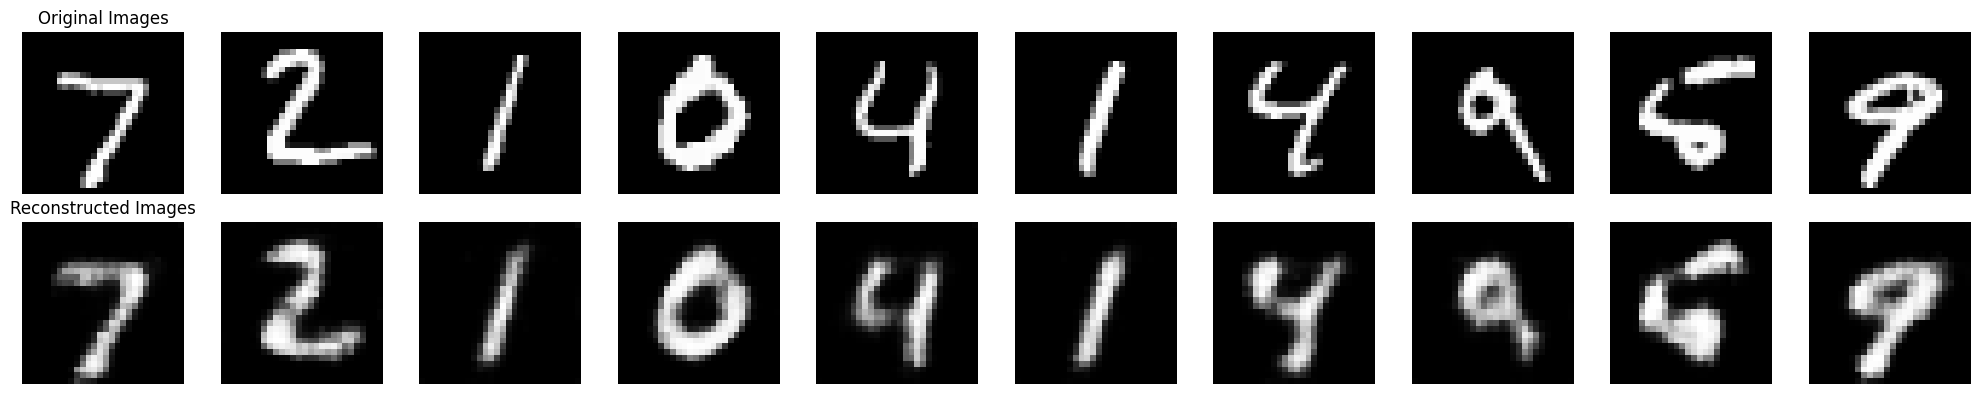

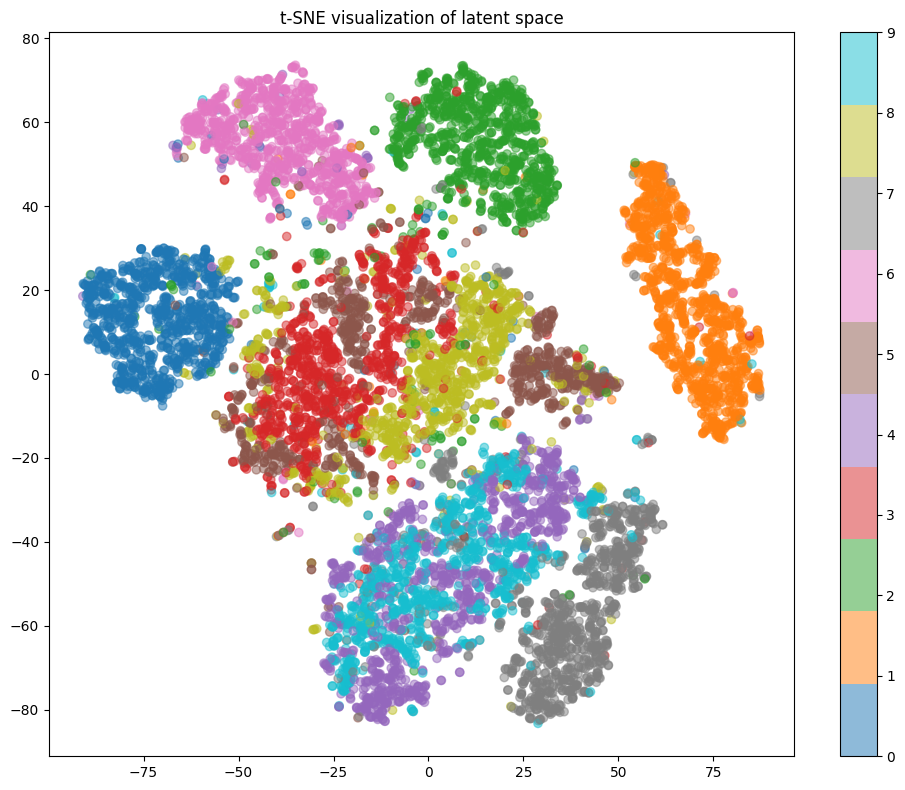

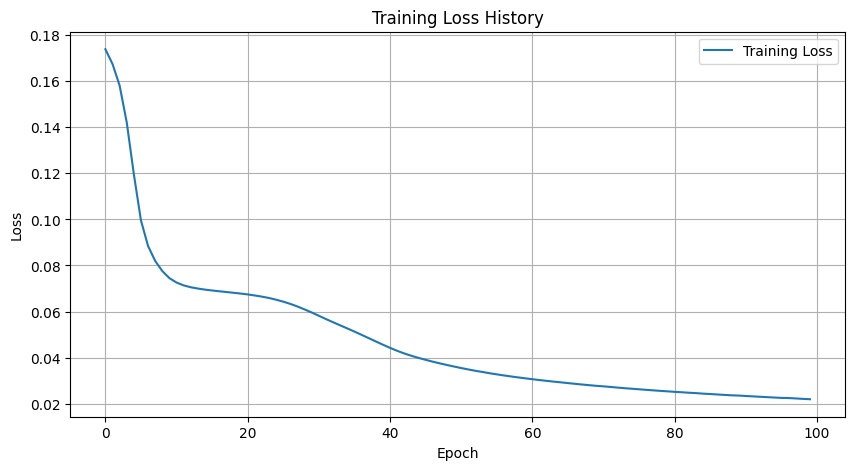

Model saved to 'autoencoder_mnist.pth'


In [12]:
def visualize_reconstruction(model, test_loader, device, num_images=10):
    model.eval()
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            reconstructions, latent_vectors = model(images)

            # Move images to CPU and convert to numpy
            images = images.cpu().numpy()
            reconstructions = reconstructions.cpu().numpy()

            # Visualize the first num_images
            plt.figure(figsize=(20, 4))
            for i in range(num_images):
                # Original images
                plt.subplot(2, num_images, i + 1)
                plt.imshow(images[i][0], cmap="gray")
                plt.axis("off")
                if i == 0:
                    plt.title("Original Images")

                # Reconstructed images
                plt.subplot(2, num_images, i + 1 + num_images)
                plt.imshow(reconstructions[i][0], cmap="gray")
                plt.axis("off")
                if i == 0:
                    plt.title("Reconstructed Images")

            plt.tight_layout()
            plt.savefig("autoencoder_reconstruction.png")
            plt.show()
            break


# Visualize the latent space for test images
def visualize_latent_space(model, test_loader, device):
    model.eval()
    latent_vectors = []
    labels = []
    with torch.no_grad():
        for images, targets in test_loader:
            images = images.to(device)
            _, latent = model(images)
            latent_vectors.append(latent.cpu().numpy())
            labels.append(targets.cpu().numpy())

    latent_vectors = np.vstack(latent_vectors)
    labels = np.concatenate(labels)

    # Apply t-SNE for dimensionality reduction to 2D
    from sklearn.manifold import TSNE

    tsne = TSNE(n_components=2, random_state=42)
    latent_2d = tsne.fit_transform(latent_vectors)

    # Visualize the latent space
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        latent_2d[:, 0], latent_2d[:, 1], c=labels, cmap="tab10", alpha=0.5
    )
    plt.colorbar(scatter)
    plt.title("t-SNE visualization of latent space")
    plt.tight_layout()
    plt.savefig("latent_space_tsne.png")
    plt.show()


# Visualize loss history
def plot_loss_history(train_loss_history):
    plt.figure(figsize=(10, 5))
    plt.plot(train_loss_history, label="Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss History")
    plt.legend()
    plt.grid(True)
    plt.savefig("loss_history.png")
    plt.show()


visualize_reconstruction(model, test_loader, device)
visualize_latent_space(model, test_loader, device)
plot_loss_history(train_loss_history)
torch.save(model.state_dict(), "autoencoder_mnist.pth")
print("Model saved to 'autoencoder_mnist.pth'")